In [28]:
import numpy as np
import sklearn
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import imageio.v3 as iio
import os
from PIL import Image
import imagehash
import shutil
from sklearn.model_selection import train_test_split


# Data loading and Processing

In [29]:
Image_size = 96
Batch = 32
Random_seed = 42

In [30]:
def remove_duplicates_smart(paths, labels, class_to_idx):
    unique_hashes = {}
    clean_paths, clean_labels = [], []
    no_fire_idx = class_to_idx.get('No_Fire', 2) 
    
    print(f"Checking {len(paths)} files for duplicates...")
    for p, l in zip(paths, labels):
        try:
            with Image.open(p) as img:
                # Use phash to find visually identical images
                h = str(imagehash.phash(img, hash_size=8))
                if h not in unique_hashes:
                    unique_hashes[h] = p
                    clean_paths.append(p)
                    clean_labels.append(l)
                    
                #elif l == no_fire_idx:
                    # Per your code, No_Fire duplicates are allowed to stay
                 #   clean_paths.append(p)
                  #  clean_labels.append(l)
        except:
            continue
    return clean_paths, clean_labels

base_dir = "Training_Tri/"
class_names = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
class_to_idx = {name: i for i, name in enumerate(class_names)}

all_p, all_l = [], []
for class_name in class_names:
    c_path = os.path.join(base_dir, class_name)
    files = [os.path.join(c_path, f) for f in os.listdir(c_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_p.extend(files)
    all_l.extend([class_to_idx[class_name]] * len(files))

clean_p, clean_l = remove_duplicates_smart(all_p, all_l, class_to_idx)

# First, split into Training and Test (e.g., 20% for Test)
train_val_p, test_p, train_val_l, test_l = train_test_split(
    clean_p, clean_l, test_size=0.2, random_state=42, stratify=clean_l
)

# Now, get Validation FROM the new Training set (e.g., 15% of the remaining training data)
train_p, val_p, train_l, val_l = train_test_split(
    train_val_p, train_val_l, test_size=0.15, random_state=42, stratify=train_val_l
)

def move_to_folders(paths, labels, root_folder):
    for p, l in zip(paths, labels):
        dest_dir = os.path.join(root_folder, class_names[l])
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy2(p, os.path.join(dest_dir, os.path.basename(p)))

print("Moving files to Ternary folders...")
move_to_folders(train_p, train_l, "Ternary_Training")
move_to_folders(test_p, test_l, "Ternary_Test")
move_to_folders(val_p, val_l, "Ternary_Validation")

print(f"Done! Final counts -> Train: {len(train_p)}, Val: {len(val_p)}, Test: {len(test_p)}")

Checking 39375 files for duplicates...
Moving files to Ternary folders...
Done! Final counts -> Train: 6154, Val: 1086, Test: 1810


In [31]:
def check_leakage_by_class(tr_p, tr_l, te_p, te_l):
    train_hashes = {}
    for p, l in zip(tr_p, tr_l):
        with Image.open(p) as img:
            h = str(imagehash.phash(img))
            train_hashes[h] = l

    for cls in np.unique(te_l):
        cls_paths = [p for p, l in zip(te_p, te_l) if l == cls]
        leak = 0
        for p in cls_paths:
            with Image.open(p) as img:
                h = str(imagehash.phash(img))
                if h in train_hashes:
                    leak += 1
        print(f"Class {cls}: {leak}/{len(cls_paths)} leaked ({100*leak/len(cls_paths):.1f}%)")

check_leakage_by_class(train_p, train_l, test_p, test_l)
# Undersample all classes to match the smallest class
from collections import Counter

counts = Counter(train_l)
print(f"Before balancing: {dict(counts)}")

min_count = min(counts.values())
print(f"Limiting each class to: {min_count} samples")

import random

def balance_split(paths, labels, seed=Random_seed):
    counts = Counter(labels)
    min_count = min(counts.values())
    combined = list(zip(paths, labels))
    random.seed(seed)
    random.shuffle(combined)
    bal_p, bal_l = [], []
    class_seen = Counter()
    for p, l in combined:
        if class_seen[l] < min_count:
            bal_p.append(p)
            bal_l.append(l)
            class_seen[l] += 1
    return bal_p, bal_l

train_p, train_l = balance_split(train_p, train_l)
val_p,   val_l   = balance_split(val_p,   val_l)
test_p,  test_l  = balance_split(test_p,  test_l)

print(f"Train: {Counter(train_l)}")
print(f"Val:   {Counter(val_l)}")
print(f"Test:  {Counter(test_l)}")


Class 0: 0/1032 leaked (0.0%)
Class 1: 0/535 leaked (0.0%)
Class 2: 0/243 leaked (0.0%)
Before balancing: {0: 3506, 1: 1821, 2: 827}
Limiting each class to: 827 samples
Train: Counter({1: 827, 2: 827, 0: 827})
Val:   Counter({1: 146, 0: 146, 2: 146})
Test:  Counter({2: 243, 0: 243, 1: 243})


In [32]:
def focal_loss_sparse(gamma, alpha):
    def loss(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        
        # One-hot encode y_true
        y_true_one_hot = tf.one_hot(y_true, depth=y_pred.shape[-1])
        
        # Cross entropy
        ce = -tf.reduce_sum(y_true_one_hot * tf.math.log(y_pred), axis=-1)
        
        # Focal weight
        p_t = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)
        focal_weight = alpha * tf.pow(1 - p_t, gamma)
        
        return tf.reduce_mean(focal_weight * ce)
    return loss

def apply_blur(img):
    img = tf.expand_dims(img, 0)  
    img = tf.nn.avg_pool2d(img, ksize=3, strides=1, padding='SAME')
    return tf.squeeze(img, 0) 

def augment(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))    
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.7, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.6)
    image = tf.image.random_hue(image, max_delta=0.05)

    # Haze
    #haze_intensity = tf.random.uniform((), 0.05, 0.25)
    #haze = tf.ones_like(image) * 0.7
    #image = tf.cond(
     #   tf.random.uniform(()) > 0.5,
      #  lambda: image * (1 - haze_intensity) + haze * haze_intensity,
       # lambda: image
    #)

    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def compute_class_weights_Tri(ds):
    labels = np.concatenate([y.numpy() for _, y in ds.batch(512)])    
    classes = np.unique(labels)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=labels)
    class_weights = dict(zip(classes, weights))
    print(f"Class weights: {class_weights}")
    return class_weights


def load_and_preprocess(path, label):
    # 1. Read the image file
    image = tf.io.read_file(path)
    # 2. Decode the JPEG/PNG image to a uint8 tensor
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    # 3. Resize the image to the global Image_size (96, 96)
    image = tf.image.resize(image, [Image_size, Image_size])
    
    return image, label

In [33]:
# 1. Training Dataset - Use 'train_p' and 'train_l'
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_p, train_l)) 
    .shuffle(len(train_p), seed=Random_seed)
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)

# 2. Validation Dataset - (val_p and val_l are usually correct)
val_ds = (
    tf.data.Dataset.from_tensor_slices((val_p, val_l))
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

# 3. Test Dataset - Use 'test_p' and 'test_l' (Fixed te_p -> test_p)
test_ds = (
    tf.data.Dataset.from_tensor_slices((test_p, test_l)) 
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

# 4. Raw Dataset for Weights - Use 'train_p' and 'train_l' (Fixed tr_p -> train_p)
train_raw_for_weights = (
    tf.data.Dataset.from_tensor_slices((train_p, train_l))
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
)

# Calculate weights
class_weights = compute_class_weights_Tri(train_raw_for_weights)

Class weights: {0: 1.0, 1: 1.0, 2: 1.0}


In [34]:

model = keras.models.Sequential([
    keras.layers.Input(shape=(96, 96, 3)),

    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.2),

    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.3),

    keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.3),

    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(3, activation='softmax')
])



model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',  # something that actually exists
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7
    ),
    keras.callbacks.ModelCheckpoint(
        'best_fire_model.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min'
    )
]

history = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    class_weight= class_weights,
    callbacks=callbacks
)

Epoch 1/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.3333 - loss: 1.0854 - val_accuracy: 0.3333 - val_loss: 1.0752 - learning_rate: 1.0000e-04
Epoch 2/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.3422 - loss: 1.0526 - val_accuracy: 0.4110 - val_loss: 1.0277 - learning_rate: 1.0000e-04
Epoch 3/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4619 - loss: 0.9911 - val_accuracy: 0.6849 - val_loss: 0.9657 - learning_rate: 1.0000e-04
Epoch 4/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5768 - loss: 0.8946 - val_accuracy: 0.6689 - val_loss: 0.8285 - learning_rate: 1.0000e-04
Epoch 5/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6239 - loss: 0.7932 - val_accuracy: 0.6986 - val_loss: 0.6928 - learning_rate: 1.0000e-04
Epoch 6/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6461 - loss: 0.7082 - val_accuracy: 0.6461 - val_loss: 0.6205 - learning_rate: 1.0000e-04
Epoch 7/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.6413 

In [35]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. POPULATE THE DATA (The missing step)
true_labels = []
y_pred_prob = []

print("Running model on test data...")
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    true_labels.extend(labels.numpy())
    y_pred_prob.extend(preds)

true_labels = np.array(true_labels)
y_pred_prob = np.array(y_pred_prob)

FIRE_THRESHOLD = 0.5

LAKE_THRESHOLD = 0.5

final_preds = []
# Replace your threshold loop with this:
final_preds = np.argmax(y_pred_prob, axis=1)
        
final_preds = np.array(final_preds)

# 3. PRINT ACCURATE RESULTS
print("\nAdjusted Classification Report:")
# Assuming your classes are 0: Fire, 1: Lake, 2: No_Fire based on your folder structure
print(classification_report(true_labels, final_preds, target_names=['Fire', 'Lake', 'No_Fire']))

print("\nAdjusted Confusion Matrix:")
print(confusion_matrix(true_labels, final_preds))


Running model on test data...

Adjusted Classification Report:
              precision    recall  f1-score   support

        Fire       0.70      0.70      0.70       243
        Lake       0.98      1.00      0.99       243
     No_Fire       0.69      0.69      0.69       243

    accuracy                           0.79       729
   macro avg       0.79      0.79      0.79       729
weighted avg       0.79      0.79      0.79       729


Adjusted Confusion Matrix:
[[169   0  74]
 [  0 243   0]
 [ 71   5 167]]


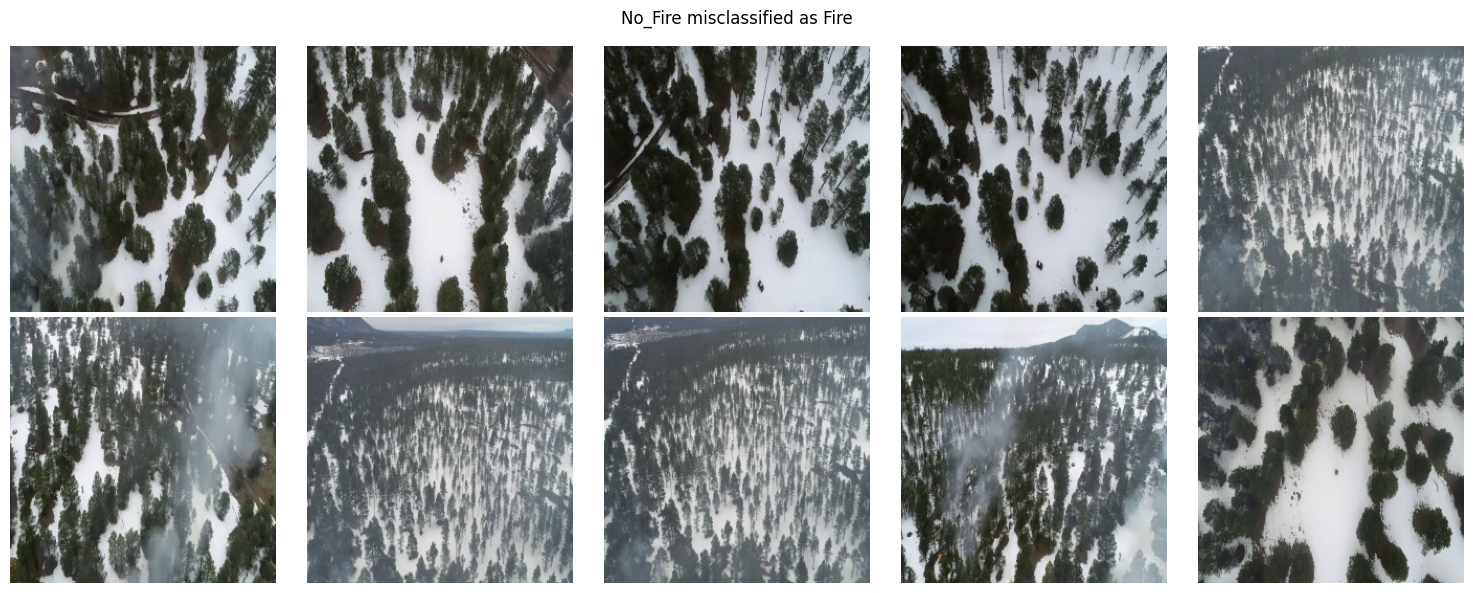

In [36]:
true_labels_arr = np.array(true_labels)
final_preds_arr = np.array(final_preds)

# Find No_Fire images predicted as Fire
no_fire_idx = class_to_idx['No_Fire']
fire_idx = class_to_idx['Fire']

misclassified = [
    test_p[i] for i in range(len(test_p))
    if true_labels_arr[i] == no_fire_idx and final_preds_arr[i] == fire_idx
]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, path in zip(axes.flat, misclassified[:10]):
    img = Image.open(path)
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('No_Fire misclassified as Fire')
plt.tight_layout()
plt.show()

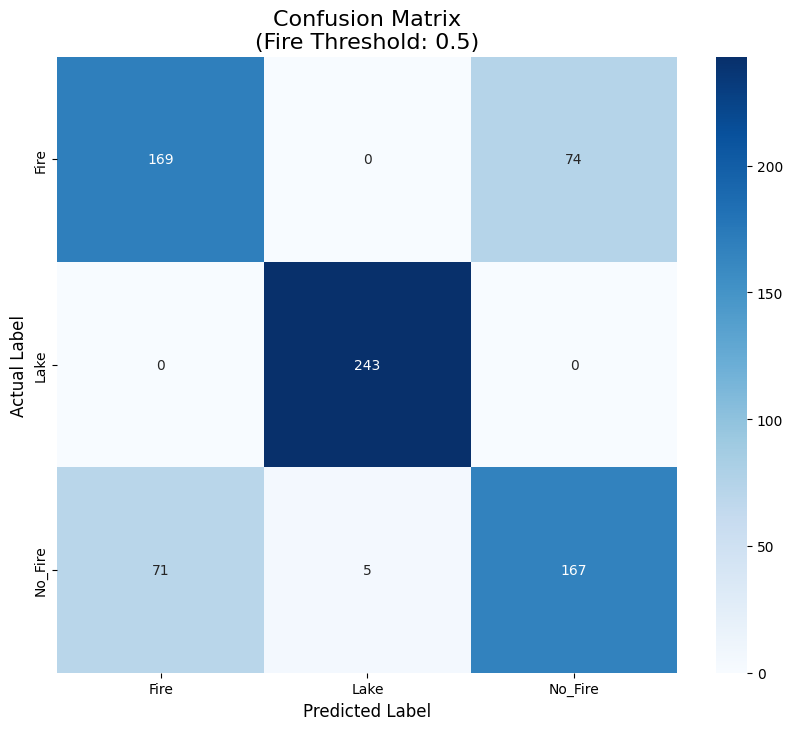

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate the confusion matrix using your final_preds
cm = confusion_matrix(true_labels, final_preds)

# 2. Set up the figure
plt.figure(figsize=(10, 8))

# 3. Create the heatmap
sns.heatmap(
    cm, 
    annot=True,          # Put the numbers in the boxes
    fmt='d',             # Use integers instead of scientific notation
    cmap='Blues',        # Color theme
    xticklabels=['Fire', 'Lake', 'No_Fire'], 
    yticklabels=['Fire', 'Lake', 'No_Fire']
)

# 4. Add labels and title
plt.title(f'Confusion Matrix\n(Fire Threshold: {FIRE_THRESHOLD})', fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

In [38]:
# Try a list of thresholds to see the effect on No_Fire Recall
for t in [0.40, 0.45, 0.5, 0.55]:
    test_preds = []
    for prob in y_pred_prob:
        if prob[0] > t: # Fire
            test_preds.append(0)
        elif prob[1] > 0.90: # Lake
            test_preds.append(1)
        else:
            test_preds.append(2) # No_Fire
            
    report = classification_report(true_labels, test_preds, output_dict=True, target_names=['Fire', 'Lake', 'No_Fire'])
    print(f"Threshold {t} -> No_Fire Recall: {report['No_Fire']['recall']:.2f} | Fire Precision: {report['Fire']['precision']:.2f}")

Threshold 0.4 -> No_Fire Recall: 0.12 | Fire Precision: 0.53
Threshold 0.45 -> No_Fire Recall: 0.33 | Fire Precision: 0.59
Threshold 0.5 -> No_Fire Recall: 0.72 | Fire Precision: 0.71
Threshold 0.55 -> No_Fire Recall: 0.97 | Fire Precision: 0.60


In [39]:
def build_fire_model_scaled(model_size='medium', loss_fn=None):
    scales = {
        'very_small': (2, 4, 8),   
        'small':      (3, 8, 12),  
        'medium':     (4, 8, 16),  
        'large':      (4, 16, 64), 
        'very_large': (5, 32, 128) 
    }
    num_blocks, base_filters, dense_dim = scales[model_size]
    
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(96, 96, 3)))

    for i in range(num_blocks):
        filters = base_filters * (2**i)
        model.add(keras.layers.Conv2D(filters, 3, activation='relu', padding='same'))
        model.add(keras.layers.Conv2D(filters, 3, activation='relu', padding='same'))
        model.add(keras.layers.MaxPooling2D())
        model.add(keras.layers.Dropout(0.2 if i < 2 else 0.3))

    model.add(keras.layers.Conv2D(filters * 2, 3, activation='relu', padding='same'))
    model.add(keras.layers.GlobalAveragePooling2D())
    model.add(keras.layers.Dense(dense_dim, activation='relu'))
    model.add(keras.layers.Dropout(0.2))
    model.add(keras.layers.Dense(3, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=loss_fn,
        metrics=['accuracy'] # Removed precision/recall here to prevent Shape/Key Errors
    )
    return model

def run_experiment(size, loss_func, weights, callbacks):
    print(f"\n--- TESTING {size.upper()} ---")
    model = build_fire_model_scaled(size, loss_func)
    history = model.fit(train_ds, validation_data=val_ds, epochs=30, 
                        class_weight=weights, callbacks=callbacks, verbose=1)
    
    # Plotting only the metrics that exist
    metrics = ['loss', 'accuracy'] 
    plt.figure(figsize=(12, 5))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 2, i+1)
        plt.plot(history.history[metric], label='Train')
        plt.plot(history.history[f'val_{metric}'], label='Val')
        plt.title(f'{size} {metric}')
        plt.legend()
    plt.show()
    return model, history


--- TESTING VERY_SMALL ---
Epoch 1/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.3454 - loss: 0.2439 - val_accuracy: 0.3333 - val_loss: 0.2439 - learning_rate: 1.0000e-04
Epoch 2/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.3507 - loss: 0.2433 - val_accuracy: 0.3539 - val_loss: 0.2428 - learning_rate: 1.0000e-04
Epoch 3/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.3313 - loss: 0.2411 - val_accuracy: 0.3333 - val_loss: 0.2397 - learning_rate: 1.0000e-04
Epoch 4/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4051 - loss: 0.2381 - val_accuracy: 0.4521 - val_loss: 0.2361 - learning_rate: 1.0000e-04
Epoch 5/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4809 - loss: 0.2352 - val_accuracy: 0.4932 - val_loss: 0.2323 - learning_rate: 1.0000e-04
Epoch 6/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.5280 - loss: 0.2331 - val_accuracy: 0.5274 - val_loss: 0.2292 - learning_rate: 1.0000e-04
Epoch 7/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 3

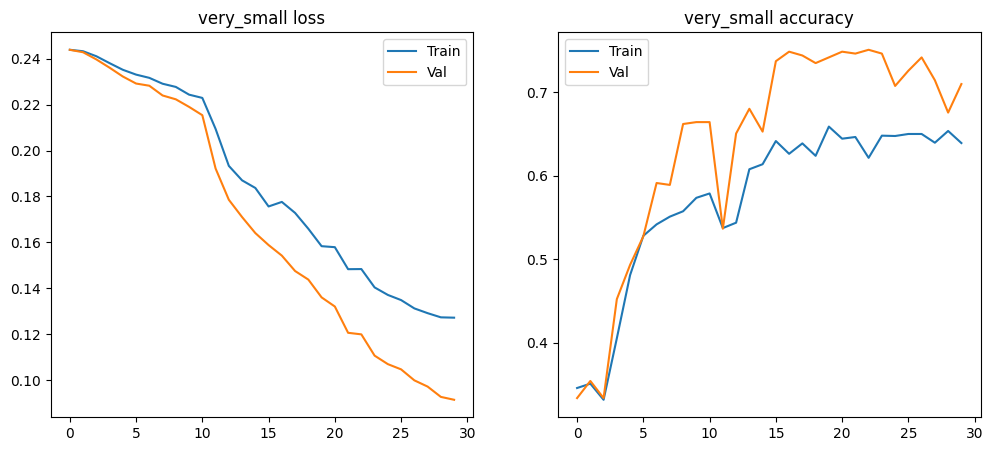


--- TESTING SMALL ---
Epoch 1/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.3547 - loss: 0.2270 - val_accuracy: 0.5479 - val_loss: 0.2070 - learning_rate: 1.0000e-04
Epoch 2/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.5635 - loss: 0.1715 - val_accuracy: 0.6598 - val_loss: 0.1316 - learning_rate: 1.0000e-04
Epoch 3/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.6385 - loss: 0.1176 - val_accuracy: 0.6735 - val_loss: 0.0795 - learning_rate: 1.0000e-04
Epoch 4/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.6655 - loss: 0.0951 - val_accuracy: 0.7100 - val_loss: 0.0717 - learning_rate: 1.0000e-04
Epoch 5/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.6590 - loss: 0.0928 - val_accuracy: 0.6849 - val_loss: 0.0693 - learning_rate: 1.0000e-04
Epoch 6/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.6546 - loss: 0.0912 - val_accuracy: 0.6826 - val_loss: 0.0690 - learning_rate: 1.0000e-04
Epoch 7/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/s

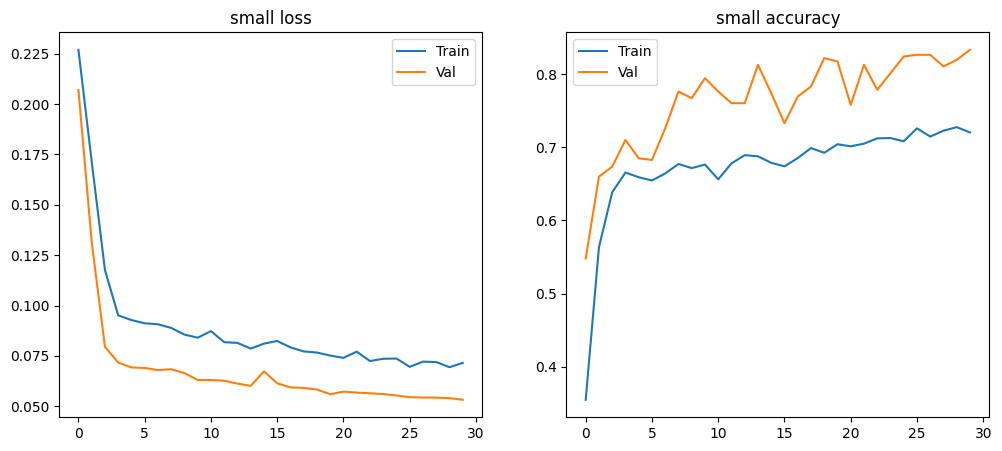


--- TESTING MEDIUM ---
Epoch 1/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3543 - loss: 0.2301 - val_accuracy: 0.5205 - val_loss: 0.2174 - learning_rate: 1.0000e-04
Epoch 2/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5828 - loss: 0.1620 - val_accuracy: 0.6484 - val_loss: 0.1112 - learning_rate: 1.0000e-04
Epoch 3/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6191 - loss: 0.1099 - val_accuracy: 0.6370 - val_loss: 0.1040 - learning_rate: 1.0000e-04
Epoch 4/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6634 - loss: 0.0909 - val_accuracy: 0.6484 - val_loss: 0.0917 - learning_rate: 5.0000e-05
Epoch 5/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.6780 - loss: 0.0921 - val_accuracy: 0.6530 - val_loss: 0.0825 - learning_rate: 5.0000e-05


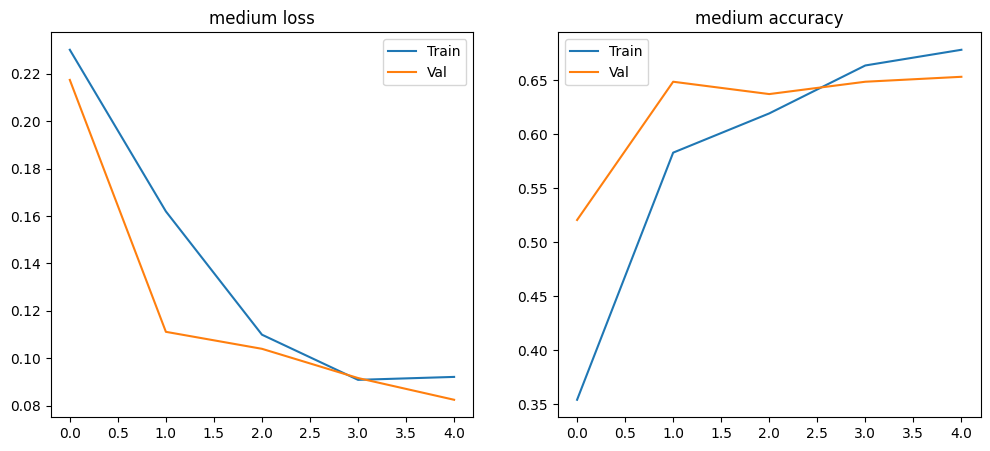

In [40]:
# Configure your variables
focal_loss = focal_loss_sparse(gamma=2.0, alpha=0.5)
my_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

# Run the test
all_results = {}
for model_size in ['very_small', 'small', 'medium']:
    all_results[model_size] = run_experiment(model_size, focal_loss, class_weights, my_callbacks)

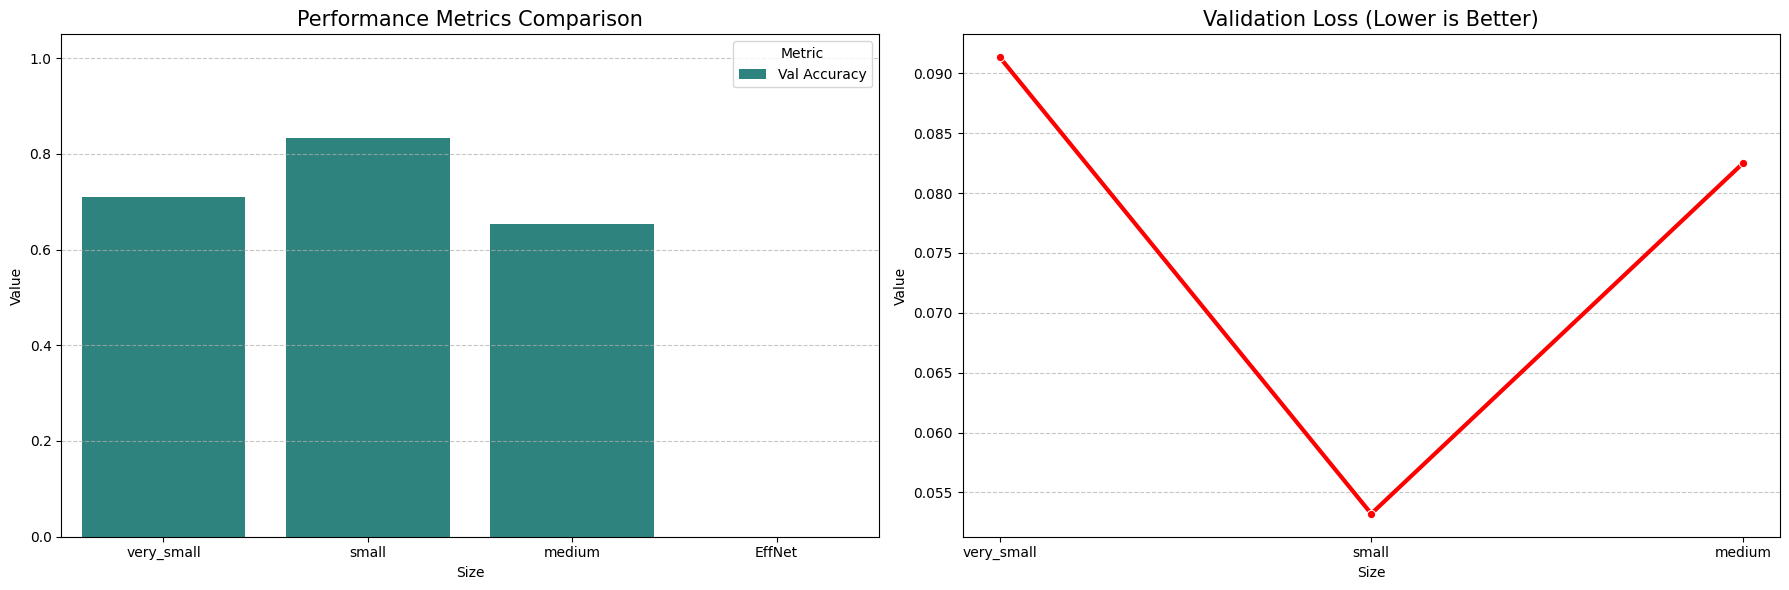

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_model_comparison(results_dict):
    # 1. Extract final metrics from each history object
    data = []
    for size, history in results_dict.items():
        # Get the index of the best val_loss (best model)
        best_epoch = np.argmin(history.history['val_loss'])
        
        row = {
            'Size': size,
            'Val Accuracy': history.history['val_accuracy'][best_epoch],
            'Val Loss': history.history['val_loss'][best_epoch],
        }
        # Add precision/recall if they exist (for Binary)
        if 'val_precision' in history.history:
            row['Val Precision'] = history.history['val_precision'][best_epoch]
            row['Val Recall'] = history.history['val_recall'][best_epoch]
            
        data.append(row)

    df = pd.DataFrame(data)
    
    # Define the order for the X-axis
    order = ['very_small', 'small', 'medium', 'large', 'very_large']
    df['Size'] = pd.Categorical(df['Size'], categories=order, ordered=True)
    df = df.sort_values('Size')

    # 2. Create the "Pretty" Plot
    # We use a long-form format for Seaborn
    df_melted = df.melt(id_vars='Size', var_name='Metric', value_name='Value')
    
    # Separate Loss from other metrics for better scale
    df_metrics = df_melted[df_melted['Metric'] != 'Val Loss']
    df_loss = df_melted[df_melted['Metric'] == 'Val Loss']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Left Plot: Accuracy/Precision/Recall
    sns.barplot(data=df_metrics, x='Size', y='Value', hue='Metric', ax=ax1, palette='viridis')
    ax1.set_title('Performance Metrics Comparison', fontsize=15)
    ax1.set_ylim(0, 1.05)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # Right Plot: Loss (Lower is better)
    sns.lineplot(data=df_loss, x='Size', y='Value', marker='o', ax=ax2, color='red', linewidth=3)
    ax2.set_title('Validation Loss (Lower is Better)', fontsize=15)
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# To run it:
# plot_model_comparison(all_results)
def plot_model_comparison(results_dict):
    data = []
    for size, result in results_dict.items():
        # 1. Handle the tuple (model, history)
        # In your run_experiment, index 0 is model, index 1 is history
        if isinstance(result, tuple):
            history_obj = result[1] 
        else:
            history_obj = result
        
        # 2. Extract the actual dictionary of metrics
        h = history_obj.history 
        
        # 3. Use 'h' (the dictionary) to find the best epoch
        best_epoch = np.argmin(h['val_loss'])
        
        row = {
            'Size': size,
            'Val Accuracy': h['val_accuracy'][best_epoch],
            'Val Loss': h['val_loss'][best_epoch],
        }
        
        # 4. Check for optional metrics using the dict 'h'
        if 'val_precision' in h:
            row['Val Precision'] = h['val_precision'][best_epoch]
            row['Val Recall'] = h['val_recall'][best_epoch]
            
        data.append(row)

    # --- Rest of your plotting code stays the same ---
    df = pd.DataFrame(data)
    order = ['very_small', 'small', 'medium','EffNet']
    df['Size'] = pd.Categorical(df['Size'], categories=order, ordered=True)
    df = df.sort_values('Size')

    df_melted = df.melt(id_vars='Size', var_name='Metric', value_name='Value')
    df_metrics = df_melted[df_melted['Metric'] != 'Val Loss']
    df_loss = df_melted[df_melted['Metric'] == 'Val Loss']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    sns.barplot(data=df_metrics, x='Size', y='Value', hue='Metric', ax=ax1, palette='viridis')
    ax1.set_title('Performance Metrics Comparison', fontsize=15)
    ax1.set_ylim(0, 1.05)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    sns.lineplot(data=df_loss, x='Size', y='Value', marker='o', ax=ax2, color='red', linewidth=3)
    ax2.set_title('Validation Loss (Lower is Better)', fontsize=15)
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
# To run it:
plot_model_comparison(all_results)

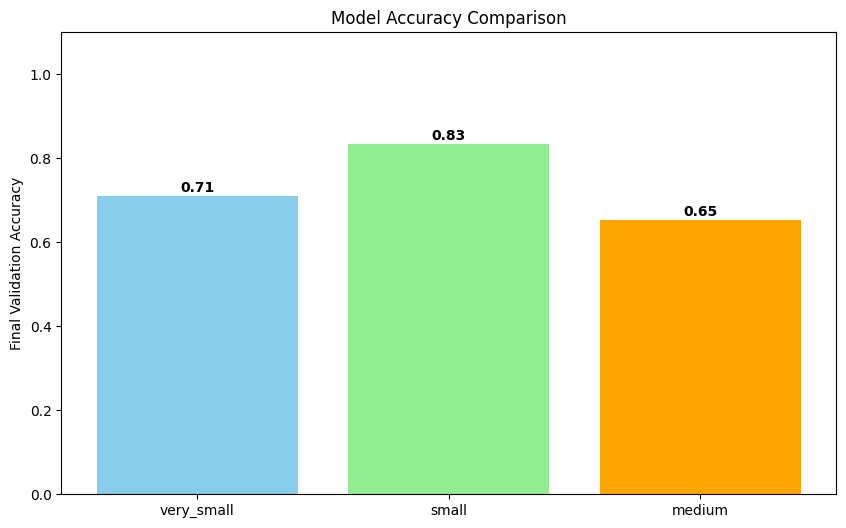

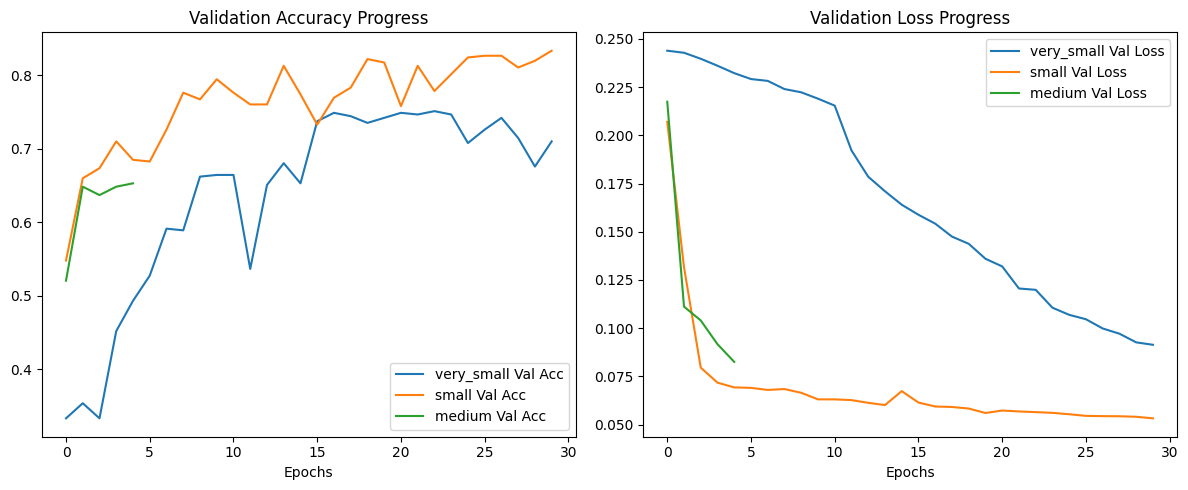

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_model_analysiss(results_dict):
    # --- 1. DATA PROCESSING FOR BAR CHART ---
    data = []
    for size, result in results_dict.items():
        # Handle the (model, history) tuple from run_experiment
        history_obj = result[1] if isinstance(result, tuple) else result
        h = history_obj.history 
        
        # Find best epoch based on validation loss
        best_epoch = np.argmin(h['val_loss'])
        
        row = {
            'Size': size,
            'Accuracy': h['val_accuracy'][best_epoch],
        }
        # Add Precision/Recall if they exist in your compiled metrics
        if 'val_precision' in h: row['Precision'] = h['val_precision'][best_epoch]
        if 'val_recall' in h: row['Recall'] = h['val_recall'][best_epoch]
            
        data.append(row)

    df = pd.DataFrame(data)
    order = ['very_small', 'small', 'medium','EffNet']
    existing_order = [o for o in order if o in df['Size'].unique()]
    df['Size'] = pd.Categorical(df['Size'], categories=existing_order, ordered=True)
    df = df.sort_values('Size')

    # --- 2. SETUP PLOTS ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    colors = sns.color_palette("viridis", len(df))

    # --- LEFT: BAR PLOT (Accuracy/Precision/Recall) ---
    df_melted = df.melt(id_vars='Size', var_name='Metric', value_name='Value')
    sns.barplot(data=df_melted, x='Size', y='Value', hue='Metric', ax=ax1, palette='magma')
    ax1.set_title('Final Model Performance Comparison', fontsize=15, fontweight='bold')
    ax1.set_ylim(0, 1.1)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add values on top of bars
    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='baseline', fontsize=9, xytext=(0, 5), textcoords='offset points')

    # --- RIGHT: LINE PLOT (Loss Plateaus over Epochs) ---
    for (size, result), color in zip(results_dict.items(), colors):
        history_obj = result[1] if isinstance(result, tuple) else result
        h = history_obj.history
        epochs = range(1, len(h['val_loss']) + 1)
        
        # Plot Validation Loss for each model
        ax2.plot(epochs, h['val_loss'], label=f'{size}', linewidth=2.5, color=color, marker='o', markersize=4)

    ax2.set_title('Validation Loss Plateaus (Across All Models)', fontsize=15, fontweight='bold')
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(title='Model Size')
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()
def plot_model_analysis(all_results):
    model_names = list(all_results.keys())  # Get all trained models
    num_models = len(model_names)
    
    # 1. Bar Chart for Final Accuracy
    plt.figure(figsize=(10, 6))
    final_accs = [all_results[m][1].history['val_accuracy'][-1] for m in model_names]
    
    plt.bar(model_names, final_accs, color=['skyblue', 'lightgreen', 'orange'][:num_models])
    plt.ylabel('Final Validation Accuracy')
    plt.title('Model Accuracy Comparison')
    for i, v in enumerate(final_accs):
        plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
    plt.ylim(0, 1.1)
    plt.show()

    # 2. Training Progress Lines
    plt.figure(figsize=(12, 5))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    for name in model_names:
        history = all_results[name][1]
        plt.plot(history.history['val_accuracy'], label=f'{name} Val Acc')
    plt.title('Validation Accuracy Progress')
    plt.xlabel('Epochs')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    for name in model_names:
        history = all_results[name][1]
        plt.plot(history.history['val_loss'], label=f'{name} Val Loss')
    plt.title('Validation Loss Progress')
    plt.xlabel('Epochs')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
# Run the combined analysis
plot_model_analysis(all_results)


--- TESTING EFFICIENTNETV2B0 (TERNARY) ---
Epoch 1/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 39s 192ms/step - accuracy: 0.6671 - loss: 0.1518 - val_accuracy: 0.9315 - val_loss: 0.0497 - learning_rate: 1.0000e-04
Epoch 2/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 12s 157ms/step - accuracy: 0.8847 - loss: 0.0551 - val_accuracy: 0.9680 - val_loss: 0.0188 - learning_rate: 1.0000e-04
Epoch 3/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 13s 161ms/step - accuracy: 0.9141 - loss: 0.0385 - val_accuracy: 0.9886 - val_loss: 0.0095 - learning_rate: 1.0000e-04
Epoch 4/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 13s 168ms/step - accuracy: 0.9266 - loss: 0.0317 - val_accuracy: 0.9886 - val_loss: 0.0060 - learning_rate: 1.0000e-04
Epoch 5/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 13s 170ms/step - accuracy: 0.9484 - loss: 0.0242 - val_accuracy: 0.9954 - val_loss: 0.0042 - learning_rate: 1.0000e-04
Epoch 6/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 13s 167ms/step - accuracy: 0.9589 - loss: 0.0193 - val_accuracy: 0.9977 - val_loss: 0.0033 - learning_rate: 1.0000e-04
Epoch 7/30
78/

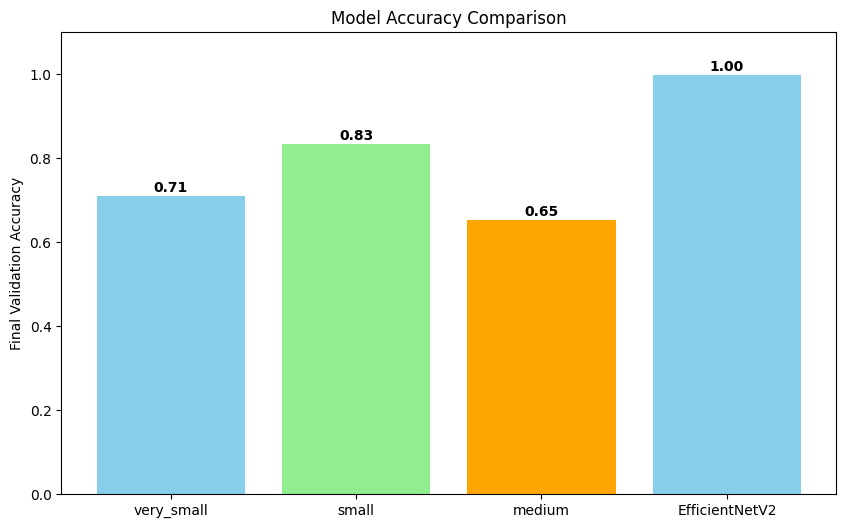

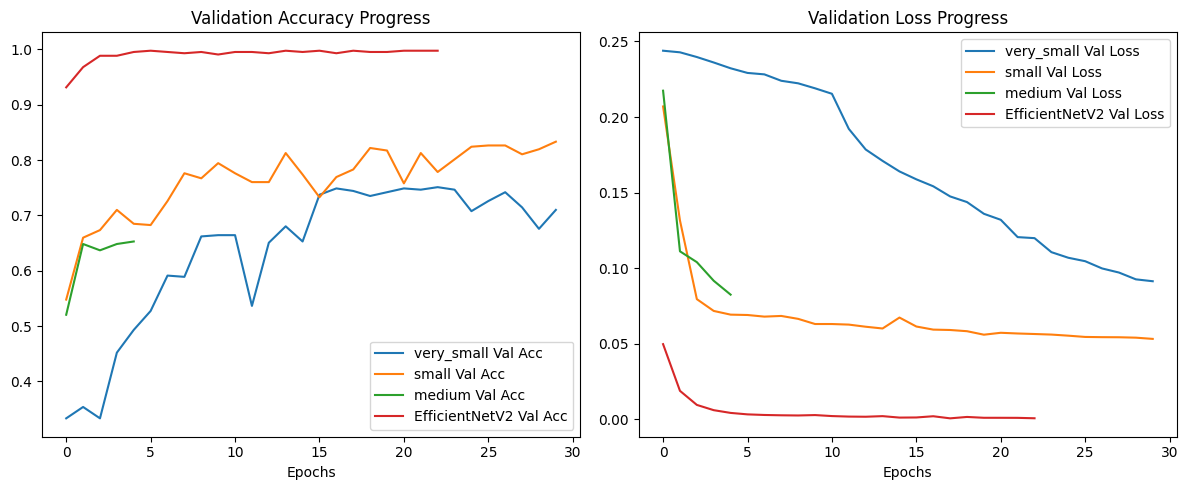

In [43]:
def build_effnet_ternary_model(loss_fn=None):
    inputs = keras.layers.Input(shape=(96, 96, 3))
    
    # Scale [0, 1] back up to [0, 255] for EfficientNetV2's internal preprocessing
    x = keras.layers.Lambda(lambda tensor: tensor * 255.0)(inputs)

    # Load pre-trained EfficientNetV2B0
    base_model = keras.applications.EfficientNetV2B0(
        include_top=False,
        weights='imagenet',
        input_tensor=x,
        input_shape=(96, 96, 3)
    )
    
    # Fine-tune the pre-trained weights
    base_model.trainable = True

    # Rebuild the top layers for 3 classes
    x = base_model.output
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(32, activation='relu')(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(3, activation='softmax')(x)

    model = keras.models.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=loss_fn,
        metrics=['accuracy']
    )
    return model

# --- Run the EfficientNetV2 Experiment ---
print("\n--- TESTING EFFICIENTNETV2B0 (TERNARY) ---")
effnet_ter_model = build_effnet_ternary_model(focal_loss)

history_effnet_ter = effnet_ter_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=my_callbacks,
    verbose=1
)

# Append to your existing results dictionary
all_results['EfficientNetV2'] = (effnet_ter_model, history_effnet_ter)

# Now, re-run your plot function to see the comparison!
plot_model_analysis(all_results)

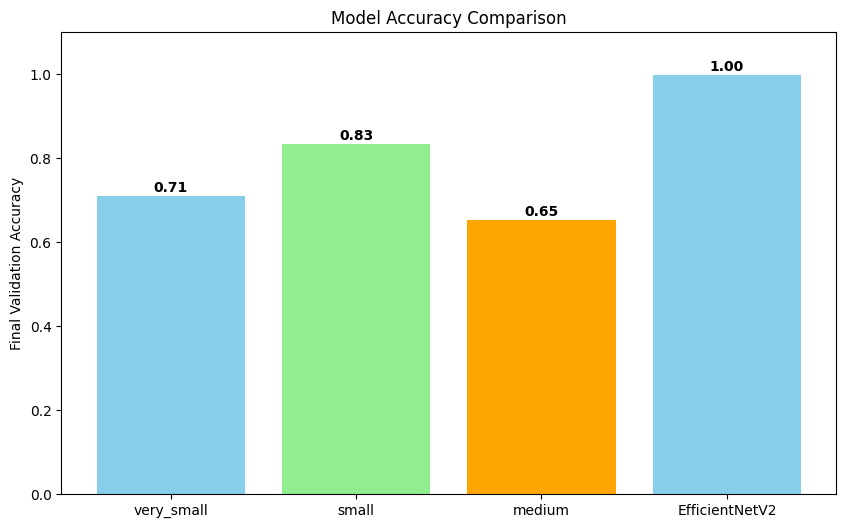

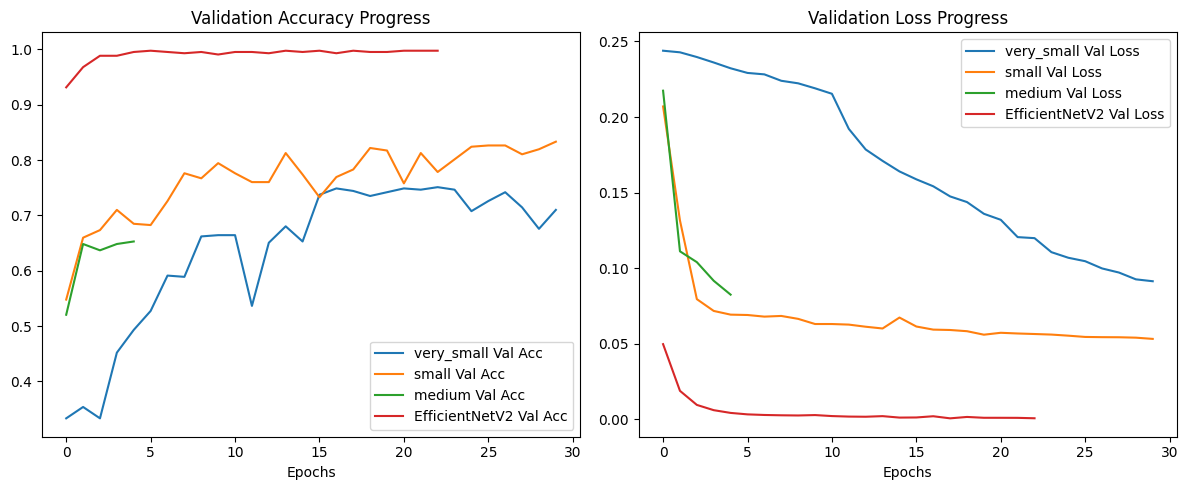

In [44]:
plot_model_analysis(all_results)